Original volume shape (D, H, W): (512, 512, 87)
Resampled shape (D, H, W): (128, 256, 256)


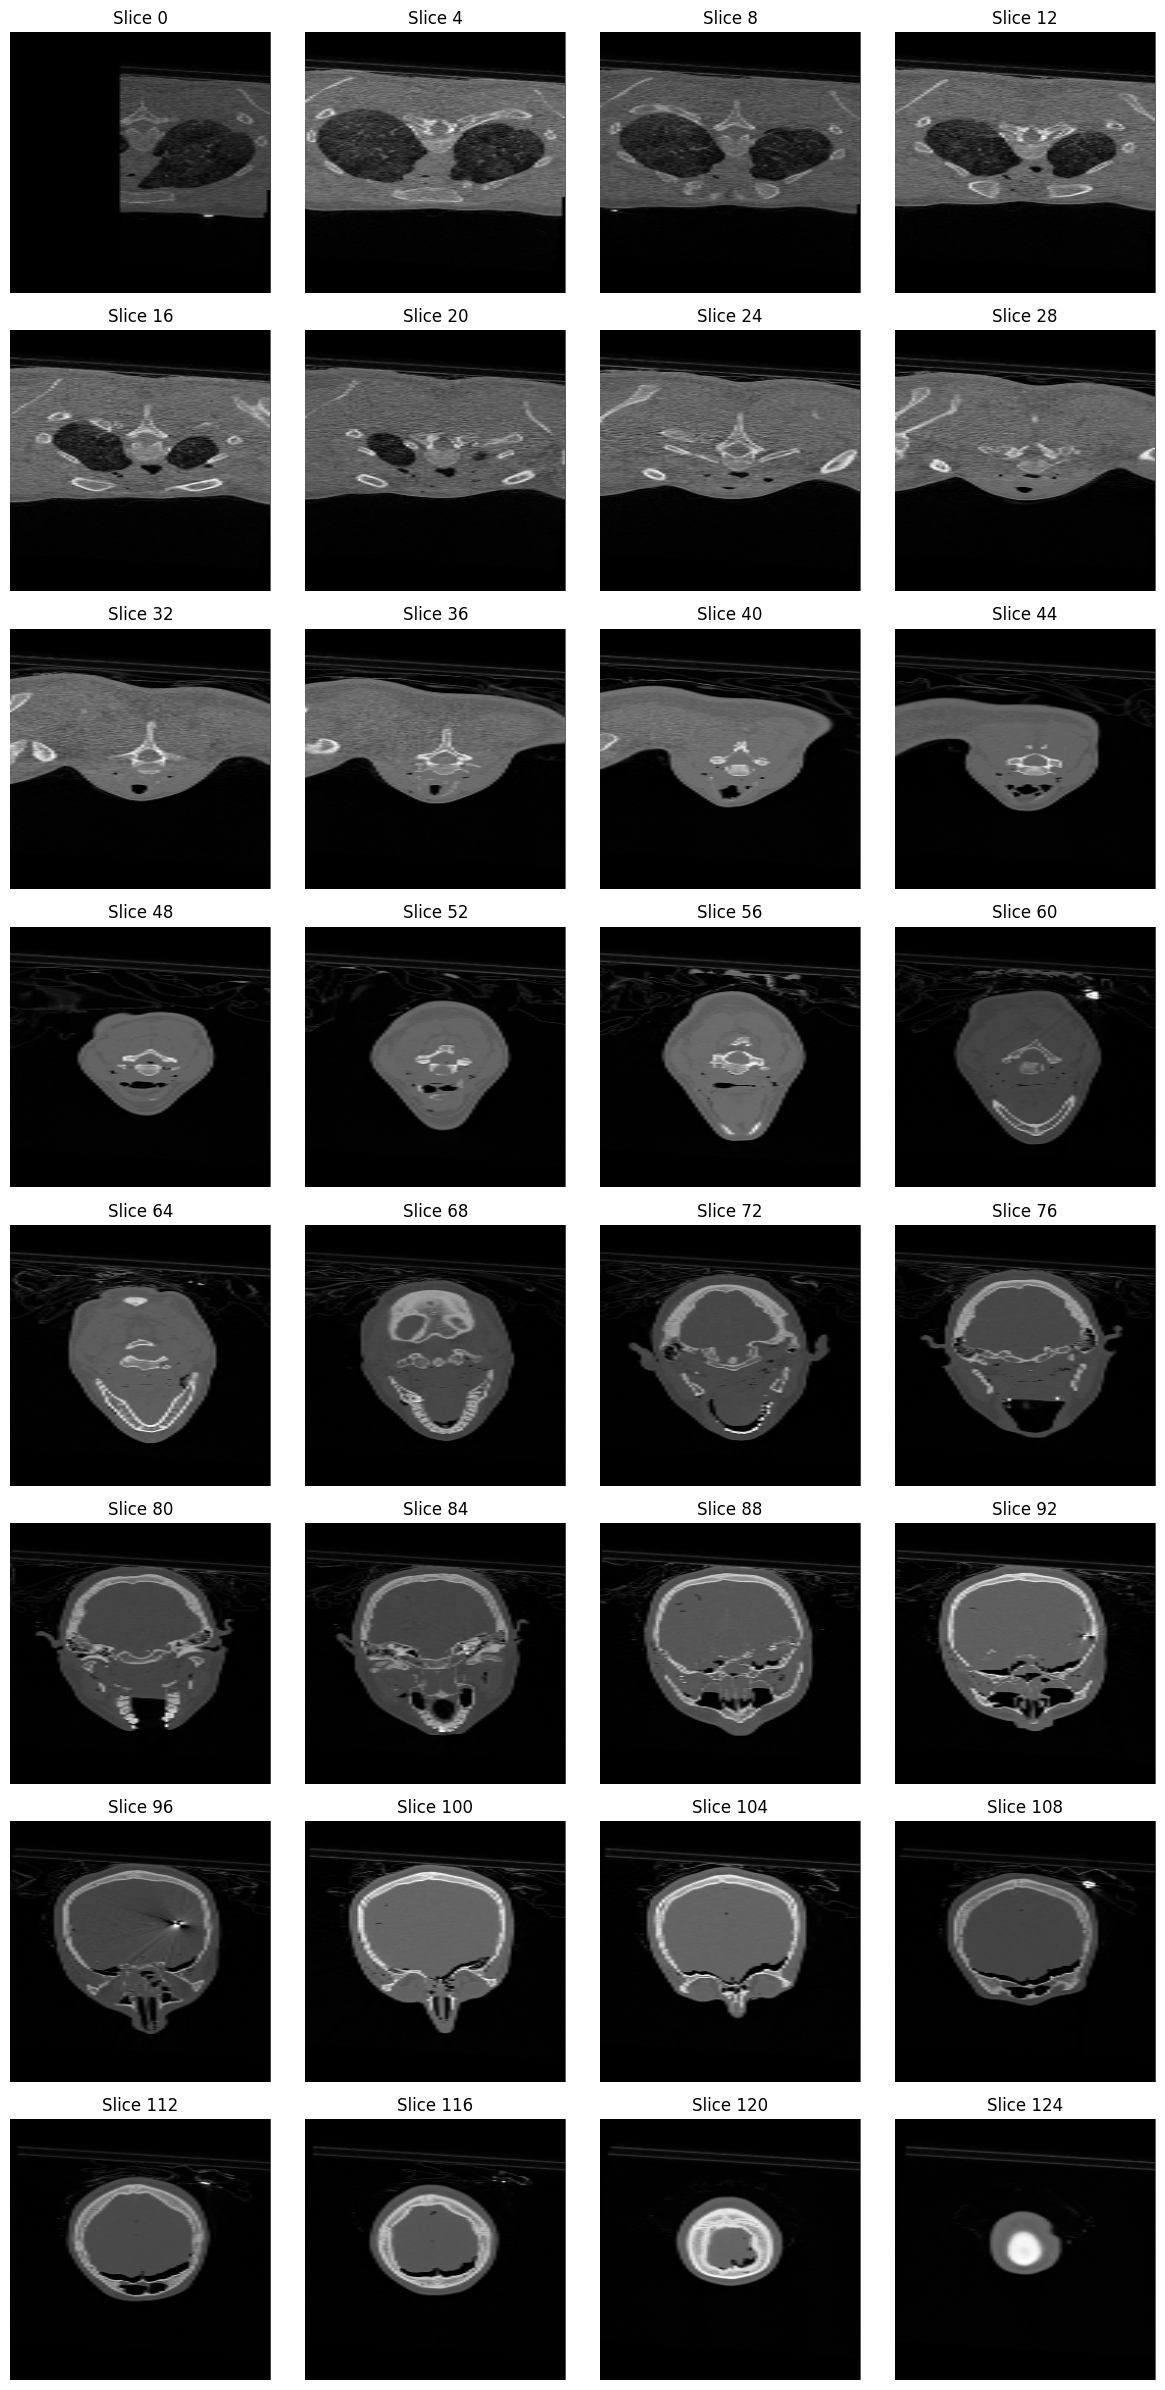

In [5]:
import SimpleITK as sitk
import numpy as np
import matplotlib.pyplot as plt

def resample_volume(img: sitk.Image, target_size=(256,256,128)) -> np.ndarray:
    orig_size    = img.GetSize()    # (W,H,D)
    orig_spacing = img.GetSpacing() # (sx,sy,sz)
    new_size     = list(target_size)
    # preserve physical extent
    new_spacing = [
        (orig_size[i] * orig_spacing[i]) / new_size[i]
        for i in range(3)
    ]
    
    resampler = sitk.ResampleImageFilter()
    resampler.SetSize(new_size)
    resampler.SetOutputSpacing(new_spacing)
    resampler.SetOutputOrigin(img.GetOrigin())
    resampler.SetOutputDirection(img.GetDirection())
    resampler.SetInterpolator(sitk.sitkLinear)
    
    out_img = resampler.Execute(img)
    return sitk.GetArrayFromImage(out_img)  # shape (D, H, W)

# --------------------------------------------------------------------
# 1) Load your chosen series from case-100012:
file = "SAG_BONE_HEAD-NECK.nii.gz"
input_path = f"/home/sdef0001/iq38_scratch/nmdid/niigz/case-100012/{file}"
img = sitk.ReadImage(input_path)
orig_array = sitk.GetArrayFromImage(img)

# 2) Print original dimensions
print("Original volume shape (D, H, W):", orig_array.shape)

# 2) Resample to (256,256,128):
vol256 = resample_volume(img, target_size=(256,256,128))

# 3) Verify the new shape:
print("Resampled shape (D, H, W):", vol256.shape)
#    → Expect: (128, 256, 256)

# 4) Plot every 4th slice to sample the depth axis:
indices = list(range(0, vol256.shape[0], 4))
cols = 4
rows = int(np.ceil(len(indices) / cols))
fig, axes = plt.subplots(rows, cols, figsize=(12, rows * 3))
for ax, idx in zip(axes.flat, indices):
    ax.imshow(vol256[idx], cmap="gray")
    ax.set_title(f"Slice {idx}")
    ax.axis("off")
for ax in axes.flat[len(indices):]:
    ax.axis("off")
plt.tight_layout()
plt.show()